In [30]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
from datetime import datetime as dt
import matplotlib.pyplot as plt

from data_loader import (
    load_secrets, get_tiingo_client, load_all_assets, clean_data,
    compute_volatility, load_tbill_data, load_equity_market_data,
    get_option_inputs,
)
from pricing import black_scholes, delta, gamma, theta, vega, rho, build_greeks_table, build_bs_price_table
from monte_carlo import simulate_terminal, build_mc_price_table
from implied_vol import iv_NR, iv_brentq, iv_solve, build_iv_table
from option_api import fetch_option_chain

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
secrets = load_secrets()
client = get_tiingo_client(secrets)

dataframes = load_all_assets()
dataframes = {key: clean_data(df) for key, df in dataframes.items()}
dataframes = {key: compute_volatility(df) for key, df in dataframes.items()}

print("Bond (Long) - ZFL.TO:", dataframes["bond1"].head())
print("Bond (Mid) - ZFM.TO:", dataframes["bond2"].head())
print("Equity - VFV.TO:", dataframes["equity"].head())
print("Gold - CGL.TO:", dataframes["gold"].head())

In [ ]:
df_tbill = load_tbill_data()
df_tbill.tail()

In [12]:
symbol = "NVDA"
df_nvda = load_equity_market_data(symbol, client)

optexp = dt(2026, 7, 31)   # expiration date matches the option chain queried below

inputs = get_option_inputs(df_nvda, df_tbill, optexp)
S = inputs["S"]
T = inputs["T"]
r = inputs["r"]
sigma = inputs["sigma"]
valuation_date = inputs["valuation_date"]
log_returns = inputs["log_returns"]

print("Spot price (S):", S)
print("Time to expiration (T, years):", T)
print("Risk-free rate (r):", r)
print("Historical volatility (sigma):", sigma)
print("Valuation date:", valuation_date)

Spot price (S): 194.83
Time to expiration (T, years): 0.06915586551185947
Risk-free rate (r): 0.0001932338156299271
Historical volatility (sigma): 0.5191439362817476
Valuation date: 2026-07-02


In [ ]:
opt_chain, resolved_date = fetch_option_chain(
    symbol,
    optexp.strftime("%Y-%m-%d"),
    valuation_date,
    S,
    option_type="call",
    strike_pct_low=0.91,
    strike_pct_high=1.16,
)

print("Resolved valuation date:", resolved_date)
opt_chain[["strike", "bid", "ask", "Pmkt"]]

In [ ]:
K = opt_chain["strike"].tolist()
print("Strikes in range:", K)

In [19]:
bs_prices = build_bs_price_table(S, K, T, r, sigma)
bs_prices

,Strike Price,B-S Call,B-S Put
0,180.0,19.281053,4.448647
1,185.0,15.985145,6.152673
2,190.0,13.064258,8.231719
3,195.0,10.524123,10.691517
4,200.0,8.356567,13.523895
5,205.0,6.541364,16.708624
6,210.0,5.049011,20.216204
7,215.0,3.843929,24.011056
8,220.0,2.887591,28.054651
9,225.0,2.141253,32.308246


In [ ]:
greeks_call = build_greeks_table(S, K, T, r, sigma, option_type="call")
greeks_put = build_greeks_table(S, K, T, r, sigma, option_type="put")

print(f"Greeks for {symbol} call")
display(greeks_call)

print(f"Greeks for {symbol} put")
display(greeks_put)

In [18]:
mc_prices = build_mc_price_table(S, r, sigma, T, K, n_sims=10_000_000, seed=42)
mc_prices

,Strike Price,MC Call,MC Put
0,180.0,19.278700,4.445959
1,185.0,15.982412,6.149604
2,190.0,13.061242,8.228367
3,195.0,10.520822,10.687880
4,200.0,8.353049,13.520041
5,205.0,6.537723,16.704647
6,210.0,5.045138,20.211995
7,215.0,3.840337,24.007128
8,220.0,2.884528,28.051252
9,225.0,2.139057,32.305715


In [20]:
bs_iv = build_iv_table(S, opt_chain, T, r, option_type="call")
bs_iv

,Strike Price,IV,Pmkt,Price Check,Price Diff
0,180.0,0.453861,18.225,18.225,7.105427e-15
1,185.0,0.453031,14.775,14.775,1.325233e-10
2,190.0,0.437386,11.450,11.450,3.552714e-15
3,195.0,0.426089,8.625,8.625,0.000000e+00
4,200.0,0.416103,6.275,6.275,1.953993e-14
5,205.0,0.411370,4.475,4.475,5.329071e-15
6,210.0,0.410699,3.150,3.150,8.348877e-14
7,215.0,0.407884,2.130,2.130,2.516939e-08
8,220.0,0.409039,1.440,1.440,6.509504e-11
9,225.0,0.412514,0.975,0.975,2.600783e-09


In [25]:
strike_test = opt_chain["strike"].iloc[0]
pmkt_test = opt_chain["Pmkt"].iloc[0]

iv_test = iv_solve(S, strike_test, T, r, pmkt_test)
recovered_price = black_scholes(S, strike_test, T, r, iv_test, option_type="call")

print(f"Strike: {strike_test:.2f}")
print(f"Implied Vol: {iv_test:.3f}")
print(f"Historical sigma: {sigma:.3f}")
print(f"Recovered Price: {recovered_price:.4f} vs Pmkt: {pmkt_test:.4f}")

Strike: 180.00
Implied Vol: 0.454
Historical sigma: 0.519
Recovered Price: 18.2250 vs Pmkt: 18.2250


In [26]:
comparison = bs_prices.merge(mc_prices, on="Strike Price").merge(
    opt_chain[["strike", "Pmkt"]].rename(columns={"strike": "Strike Price"}),
    on="Strike Price",
    how="left",
)
comparison

,Strike Price,B-S Call,B-S Put,MC Call,MC Put,Pmkt
0,180.0,19.281053,4.448647,19.278700,4.445959,18.225
1,185.0,15.985145,6.152673,15.982412,6.149604,14.775
2,190.0,13.064258,8.231719,13.061242,8.228367,11.450
3,195.0,10.524123,10.691517,10.520822,10.687880,8.625
4,200.0,8.356567,13.523895,8.353049,13.520041,6.275
5,205.0,6.541364,16.708624,6.537723,16.704647,4.475
6,210.0,5.049011,20.216204,5.045138,20.211995,3.150
7,215.0,3.843929,24.011056,3.840337,24.007128,2.130
8,220.0,2.887591,28.054651,2.884528,28.051252,1.440
9,225.0,2.141253,32.308246,2.139057,32.305715,0.975


In [28]:
import plotly.express as px

fig = px.line(
    bs_iv.dropna(subset=["IV"]),
    x="Strike Price",
    y="IV",
    markers=True,
    title=f"{symbol} Implied Volatility Smile — Expiration {optexp.strftime('%Y-%m-%d')}",
)
fig.update_layout(yaxis_tickformat=".1%")
fig.show()

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

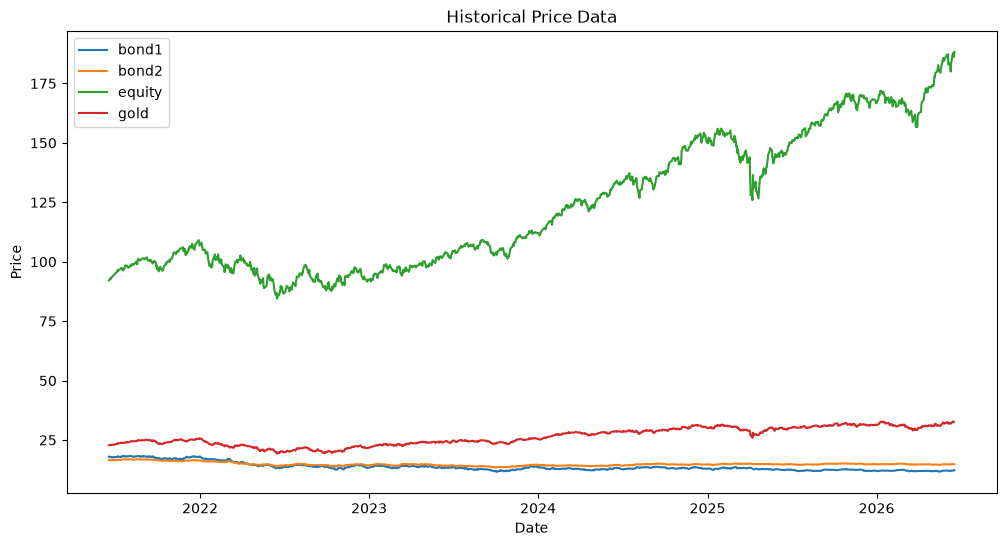

In [31]:
# Plotting historical prices for all assets
plt.figure(figsize=(12,6))
for key, df in dataframes.items():
    plt.plot(df.index, df['Close'], label=key)
plt.xlabel('Date')
plt.ylabel('Price')
plt.title('Historical Price Data')
plt.legend()
plt.show()

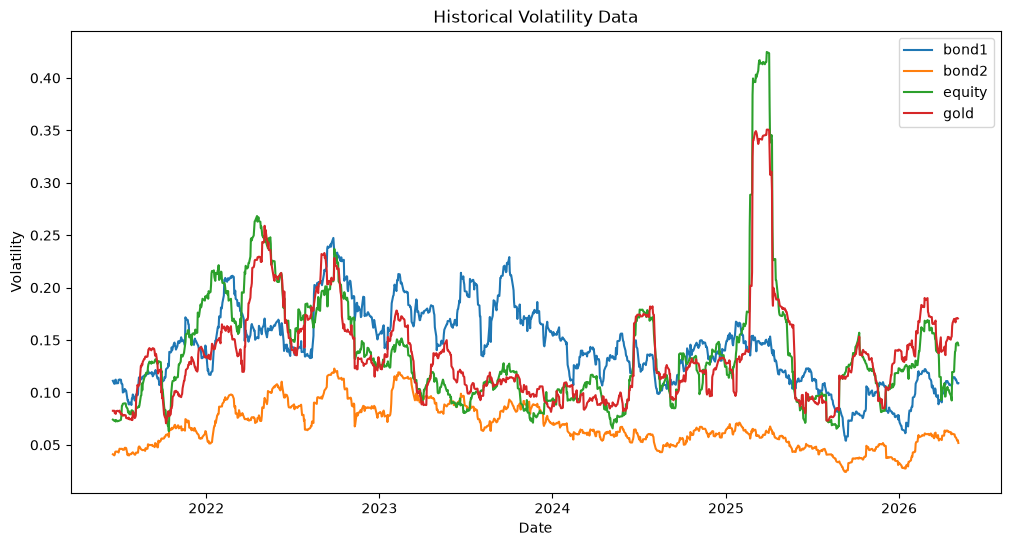

In [32]:
# Plotting volatility
plt.figure(figsize=(12,6))
for key, df in dataframes.items():
    plt.plot(df.index, df['Volatility'], label=key)
plt.xlabel('Date')
plt.ylabel('Volatility')
plt.title('Historical Volatility Data')
plt.legend()
plt.show()

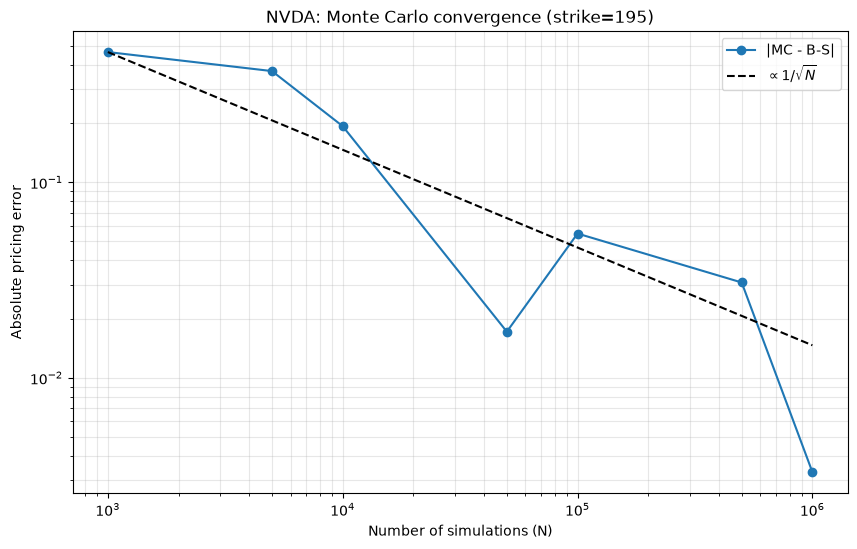

In [34]:
# Monte Carlo convergence: pricing error vs number of simulations
Ns = [1000, 5000, 10000, 50000, 100000, 500000, 1000000]

# Study one strike (ATM = closest to spot)
strike = min(K, key=lambda k: abs(k - S))
bs = black_scholes(S, strike, T, r, sigma, 'call')   # exact reference value

errors = []
for n in Ns:
    St_n = simulate_terminal(S, r, sigma, T, n)
    mc = np.exp(-r*T) * np.maximum(St_n - strike, 0).mean()
    errors.append(abs(mc - bs))

plt.figure(figsize=(10, 6))
plt.loglog(Ns, errors, 'o-', label="|MC - B-S|")
# Theoretical 1/sqrt(N) reference, anchored at the first point
plt.loglog(Ns, errors[0]*np.sqrt(Ns[0]/np.array(Ns)), 'k--', label=r"$\propto 1/\sqrt{N}$")
plt.xlabel("Number of simulations (N)")
plt.ylabel("Absolute pricing error")
plt.title(f"{symbol}: Monte Carlo convergence (strike={strike:.0f})")
plt.legend(); plt.grid(True, which='both', alpha=0.3)
plt.show()

In [ ]:
# MC: Conceptually solving MC Price(sigma) ± error = Market Price 